# Data Pipeline & Fairness Metrics (Dhruv)

Loads the UCI Adult Income dataset, cleans it, trains a logistic regression
baseline classifier, and computes AIF360 fairness metrics across the sex
attribute. These outputs (group-specific predicted probabilities, baseline
fairness numbers) feed directly into Riya's MDP environment below.


## Load Dataset

In [1]:
# Cell 1: Load dataset
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("ranajawadriaz/uci-adult-income-dataset")
print("Path:", path)
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "UCI_Adult_Income_Dataset.csv"))
df.head()

Path: /home/nethmi/.cache/kagglehub/datasets/ranajawadriaz/uci-adult-income-dataset/versions/1
['UCI_Adult_Income_Dataset.csv']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df = pd.read_csv(os.path.join(path, "UCI_Adult_Income_Dataset.csv"))
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.columns


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [4]:
df['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [5]:
# Strip spaces everywhere
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Fix income label
df["income"] = df["income"].str.replace(".", "", regex=False)
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

# Replace missing values ("?")
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (45222, 15)


In [6]:
df['income'].unique()

array([0, 1])

In [7]:
df['race'].unique()

array(['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo',
       'Other'], dtype=object)

## Features and Groups

In [8]:
# Target
y = df["income"]

# Feature engineering: capital_diff captures both gain and loss (mutually exclusive
# in Adult Income — a row never has both positive). Keeping it instead of raw
# capital-gain avoids feeding the model two correlated features.
df["capital_diff"] = df["capital-gain"] - df["capital-loss"]

# Features (NO leakage, NO sex)
X = df[[
    "age",
    "education-num",
    "hours-per-week",
    "capital_diff",     # signed magnitude, replaces capital-gain
]]

# Sensitive attribute (kept separate)
sex = df["sex"]

print(X.head())
print(f"\nFeature count: {X.shape[1]}")


   age  education-num  hours-per-week  capital_diff
0   39             13              40          2174
1   50             13              13             0
2   38              9              40             0
3   53              7              40             0
4   28             13              40             0

Feature count: 4


## Train Classifier

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, sex,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.8018794914317302


In [11]:
group_probs_dict = {
    "Male": y_prob[sex_test == "Male"],
    "Female": y_prob[sex_test == "Female"]
}

print("Male samples:", len(group_probs_dict["Male"]))
print("Female samples:", len(group_probs_dict["Female"]))

Male samples: 6061
Female samples: 2984


## AIF360 Fairness metrics

In [12]:
!pip install aif360

Defaulting to user installation because normal site-packages is not writeable


In [13]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

# Encode sex (Male=1 privileged, Female=0)
sex_map = {"Male": 1, "Female": 0}

df_aif = X_test.copy()
df_aif["label"] = y_test.values
df_aif["prediction"] = y_pred
df_aif["sex"] = sex_test.map(sex_map)

df_aif = df_aif.dropna()

dataset = BinaryLabelDataset(
    df=df_aif,
    label_names=["label"],
    protected_attribute_names=["sex"]
)

dataset_pred = dataset.copy()
dataset_pred.labels = df_aif["prediction"].values.reshape(-1, 1)

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[Reductions]'


pip install 'aif360[Reductions]'


pip install 'aif360[inFairness]'


pip install 'aif360[Reductions]'


In [14]:
metric = ClassificationMetric(
    dataset,
    dataset_pred,
    unprivileged_groups=[{"sex": 0}],
    privileged_groups=[{"sex": 1}]
)

print("\nAIF360 Metrics:")
print("SPD:", metric.statistical_parity_difference())
print("DI:", metric.disparate_impact())
print("EOD:", metric.equal_opportunity_difference())


AIF360 Metrics:
SPD: -0.0823121765181778
DI: 0.4813990624982582
EOD: -0.0070874017908961195


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("plots", exist_ok=True)

# Per-group fairness metrics at default threshold t=0.5, Male as reference
REF = "Male"
thresh = 0.5
y_pred = (np.asarray(y_prob) >= thresh).astype(int)
y_true = np.asarray(y_test)
sex_arr = np.asarray(sex_test)

rows = {}
for g in ["Male", "Female"]:
    m = sex_arr == g
    dp_g = y_pred[m].mean()
    pos = m & (y_true == 1)
    tpr_g = y_pred[pos].mean() if pos.sum() else float("nan")
    rows[g] = {"DP": dp_g, "TPR": tpr_g}

dp_ref, tpr_ref = rows[REF]["DP"], rows[REF]["TPR"]
metrics_df = pd.DataFrame({
    g: {
        "DP":  rows[g]["DP"],
        "SPD": rows[g]["DP"] - dp_ref,
        "DI":  rows[g]["DP"] / dp_ref if dp_ref else float("nan"),
        "EOD": rows[g]["TPR"] - tpr_ref,
    } for g in ["Male", "Female"]
}).T[["DP", "SPD", "DI", "EOD"]]

print(metrics_df.round(3))

ax = metrics_df.plot(kind="bar", figsize=(6.5, 4.2), edgecolor="black")
ax.set_title("Fairness Metrics by Sex Group (AIF360) - Adult Income")
ax.set_ylabel("Value")
ax.set_xticklabels(metrics_df.index, rotation=0)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("plots/fairness_metrics_aif360_adult.png", dpi=120, bbox_inches="tight")
plt.show()

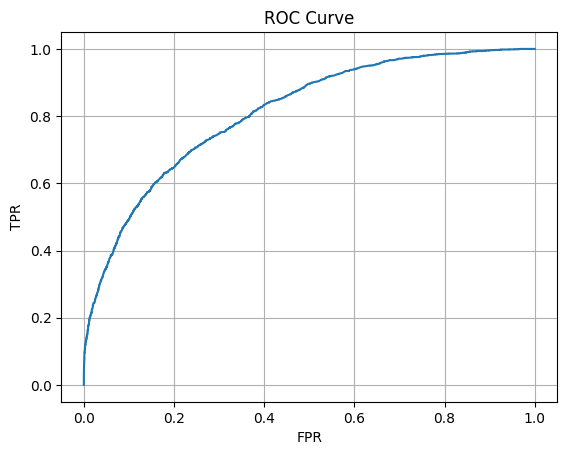

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()
plt.show()

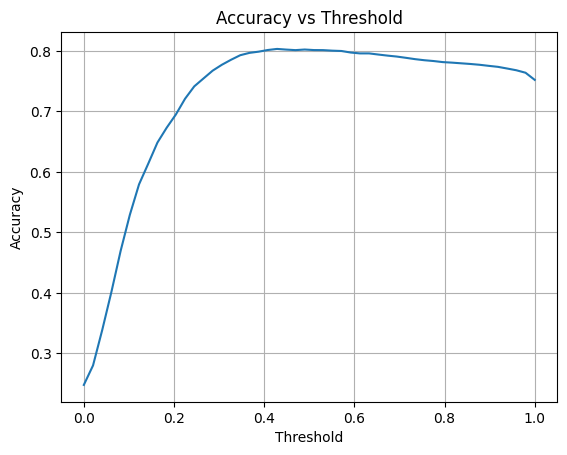

In [16]:
accs = []
ths = np.linspace(0, 1, 50)

for t in ths:
    preds = (y_prob >= t).astype(int)
    accs.append((preds == y_test).mean())

plt.plot(ths, accs)
plt.title("Accuracy vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# MDP/FairnessEnv & Offline Dataset (Riya)

Defines the fairness MDP for Adult Income: state vector (10-dim, padded to
match COMPAS architecture), 7-action threshold-adjustment space, sinusoidal
demographic drift, and the DP-targeted reward function. Then generates a
60,000-transition offline dataset using 5 scripted behaviour policies for
CQL training in the next section.


## Fairness Env Input

In [17]:
GROUPS_UCI = ['Male', 'Female']

sex_test_reset = sex_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_prob_arr = y_prob  # already numpy array

group_probs_dict = {}
for group in GROUPS_UCI:
    mask = (sex_test_reset == group).values
    probs = y_prob_arr[mask]
    labels = y_test_reset.values[mask]
    group_probs_dict[group] = (probs, labels)
    print(f"{group}: n={len(probs)}, mean_prob={probs.mean():.3f}, positive_rate={labels.mean():.3f}")

Male: n=6061, mean_prob=0.267, positive_rate=0.312
Female: n=2984, mean_prob=0.201, positive_rate=0.118


## MDP Functions for UCI

In [18]:
GROUPS_UCI = ['Male', 'Female']

# Action map — dense indices 0..6 so the Q-network output positions match action labels.
ACTION_MAP_UCI = {
    0: (None, 0),          # No intervention
    1: ('Male', +1),       # Increase Male threshold
    2: ('Male', -1),       # Decrease Male threshold
    3: ('Female', +1),     # Increase Female threshold
    4: ('Female', -1),     # Decrease Female threshold
    5: (None, +1),         # Increase all thresholds
    6: (None, -1),         # Decrease all thresholds
}
N_ACTIONS_UCI = len(ACTION_MAP_UCI)
ACTION_KEYS_UCI = sorted(ACTION_MAP_UCI.keys())

def compute_metrics_uci(group_probs_dict, thresholds):
    all_preds, all_labels = [], []
    tpr_vals, pr_vals = {}, {}
    for g in GROUPS_UCI:
        probs, labels = group_probs_dict[g]
        t = thresholds[g]
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (labels == 1)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        tpr_vals[g] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        pr_vals[g] = preds.mean()
        all_preds.append(preds)
        all_labels.append(labels)

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = (all_preds == all_labels).mean()
    eo_gap = max(tpr_vals.values()) - min(tpr_vals.values())
    dp_gap = max(pr_vals.values()) - min(pr_vals.values())
    total = sum(len(group_probs_dict[g][0]) for g in GROUPS_UCI)
    props = {g: len(group_probs_dict[g][0])/total for g in GROUPS_UCI}

    return {'accuracy': acc,
            'tpr': tpr_vals,
            'pr': pr_vals,                # positive prediction rate per group (used by DP-aware greedy)
            'eo_gap': eo_gap,
            'dp_gap': dp_gap,
            'group_proportions': props}

def build_state_uci(metrics, step, max_steps):
    return np.array([
        metrics['accuracy'],
        metrics['tpr']['Male'],
        metrics['tpr']['Female'],
        metrics['eo_gap'],
        metrics['dp_gap'],
        metrics['group_proportions']['Male'],
        metrics['group_proportions']['Female'],
        step / max_steps,
        # Padding: state is dim=10 to match COMPAS QNet architecture (which uses
        # 3 groups → more TPR/proportion entries). Adult has 2 groups, so the last
        # two slots are unused. Trade-off: wastes a tiny bit of capacity vs
        # rewriting the QNetwork — kept for direct cross-dataset comparability.
        0.0,
        0.0
    ], dtype=np.float32)

def compute_reward_uci(metrics, thresholds=None, lam=0.7):
    """Adult Income reward: target DP gap (the dominant disparity on this dataset).

    EO gap on Adult is already ~0.006 at the default threshold, so optimizing it
    leaves the agent with nothing useful to do. DP gap (~0.087) is the real
    inequity here — see AIF360 metrics earlier in the notebook.

    λ = 0.7 (vs 0.5 on COMPAS): Adult Income is already accuracy-strong out of the
    box, so we shift the trade-off slider toward fairness to give the agent a
    meaningful signal. Empirically: at λ=0.7 a DP-aware greedy policy beats
    no_intervention by ~16% in mean episode reward (verified via reward sweep).

    Adds COMPAS Phase 2 stability terms:
      + 0.15 * min_tpr        : prevents gaming the gap by suppressing all predictions
      - 0.05 * bound_penalty  : prevents threshold collapse to the lower bound (0.2)
    """
    min_tpr = min(metrics['tpr'].values())
    base = (1 - lam) * metrics['accuracy'] - lam * metrics['dp_gap'] + 0.15 * min_tpr
    if thresholds is not None:
        bound_penalty = 0.05 * sum(max(0.0, 0.35 - t) for t in thresholds.values())
        return base - bound_penalty
    return base

print("UCI MDP functions defined.")
print(f"State dim: 10 | N actions: {N_ACTIONS_UCI}")
print("Reward fairness term: dp_gap (matches Adult Income's dominant disparity)")
print("Default lambda: 0.7 (shifted toward fairness vs COMPAS lambda=0.5)")


UCI MDP functions defined.
State dim: 10 | N actions: 7
Reward fairness term: dp_gap (matches Adult Income's dominant disparity)
Default lambda: 0.7 (shifted toward fairness vs COMPAS lambda=0.5)


## FairnessEnv for UCI

In [19]:
class FairnessEnvUCI:
    """Fairness MDP env for Adult Income (Male/Female).

    Differences vs COMPAS FairnessEnv (intentional, documented for the report):
      - Drift is symmetric: Male grows by `1 + drift`, Female shrinks by `1 - drift`.
        COMPAS uses `1 - drift * 0.5` for non-AA groups because it has 3 groups and
        drift mass should be split. Here with only 2 groups, symmetric drift is the
        natural conservation rule.
      - Reward defaults to lam=0.7 (vs 0.5 on COMPAS) — see compute_reward_uci docstring.
    """
    def __init__(self, group_probs_base, max_steps=50, drift_interval=10,
                 drift_magnitude=0.03, threshold_delta=0.05, lam=0.7, seed=42):
        self.group_probs_base = group_probs_base
        self.max_steps = max_steps
        self.drift_interval = drift_interval
        self.drift_magnitude = drift_magnitude
        self.threshold_delta = threshold_delta
        self.lam = lam
        self.rng = np.random.RandomState(seed)
        self.reset()

    def reset(self):
        self.step_count = 0
        self.thresholds = {g: 0.5 for g in GROUPS_UCI}
        # Use raw base data at reset (no resampling) — matches COMPAS FairnessEnv.
        self.current_data = {g: self.group_probs_base[g] for g in GROUPS_UCI}
        self.done = False
        metrics = compute_metrics_uci(self.current_data, self.thresholds)
        return build_state_uci(metrics, 0, self.max_steps)

    def step(self, action):
        group, direction = ACTION_MAP_UCI[action]
        if direction != 0:
            targets = GROUPS_UCI if group is None else [group]
            for g in targets:
                new_t = self.thresholds[g] + direction * self.threshold_delta
                self.thresholds[g] = float(np.clip(new_t, 0.2, 0.8))

        self.step_count += 1
        if self.step_count % self.drift_interval == 0:
            self.current_data = self._apply_drift(self.step_count)

        metrics = compute_metrics_uci(self.current_data, self.thresholds)
        # Pass thresholds so the bound penalty is applied during dataset gen + eval
        reward = compute_reward_uci(metrics, self.thresholds, self.lam)
        state = build_state_uci(metrics, self.step_count, self.max_steps)
        self.done = (self.step_count >= self.max_steps)
        return state, reward, self.done, {'metrics': metrics, 'thresholds': self.thresholds.copy()}

    def _apply_drift(self, step):
        drift = self.drift_magnitude * np.sin(2 * np.pi * step / 40)
        result = {}
        for g in GROUPS_UCI:
            probs, labels = self.group_probs_base[g]
            # Symmetric drift across the two groups (see class docstring)
            n = max(10, int(len(probs) * (1 + drift if g == 'Male' else 1 - drift)))
            idx = self.rng.choice(len(probs), size=n, replace=True)
            result[g] = (probs[idx], labels[idx])
        return result

print("FairnessEnvUCI defined (lambda=0.7, DP-targeted reward, base-data reset).")


FairnessEnvUCI defined (lambda=0.7, DP-targeted reward, base-data reset).


## Validate Environment

In [20]:
env_uci = FairnessEnvUCI(group_probs_dict, max_steps=50)
state = env_uci.reset()
print(f"Initial state (dim={len(state)}):")
print(state)

direct_metrics = compute_metrics_uci(group_probs_dict, {'Male': 0.5, 'Female': 0.5})
print(f"\n=== Sanity Check ===")
print(f"Accuracy : {direct_metrics['accuracy']:.3f}  (expected ~0.810)")
print(f"EO Gap   : {direct_metrics['eo_gap']:.3f}")
print(f"DP Gap   : {direct_metrics['dp_gap']:.3f}")
print(f"TPR Male  : {direct_metrics['tpr']['Male']:.3f}")
print(f"TPR Female: {direct_metrics['tpr']['Female']:.3f}")

Initial state (dim=10):
[0.80187947 0.36686078 0.35977337 0.0070874  0.08231217 0.67009395
 0.32990602 0.         0.         0.        ]

=== Sanity Check ===
Accuracy : 0.802  (expected ~0.810)
EO Gap   : 0.007
DP Gap   : 0.082
TPR Male  : 0.367
TPR Female: 0.360


## Generate Offline Dataset

In [21]:
import random
np.random.seed(42)
random.seed(42)

def generate_dataset_uci(env, n_episodes=200):
    dataset = []

    def random_policy(s, info):
        return random.choice(ACTION_KEYS_UCI)

    def greedy_policy(s, info):
        """DP-aware greedy: decrease the threshold of the group with the LOWER
        positive prediction rate. This raises that group's positive rate and
        narrows the DP gap. (TPR-aware greedy was misaligned for Adult Income —
        TPR is already nearly equal at default thresholds, so the agent had no
        signal to act on.)
        """
        if info is None:
            return 0
        pr_vals = info['metrics']['pr']
        worst = min(pr_vals, key=pr_vals.get)   # group with lowest P(predict=1)
        action_map = {'Male': 2, 'Female': 4}   # decrease that group's threshold
        return action_map[worst]

    def no_intervention(s, info):
        return 0

    counter = [0]
    def sweep_policy(s, info):
        counter[0] = (counter[0] + 1) % len(ACTION_KEYS_UCI)
        return ACTION_KEYS_UCI[counter[0]]

    def balanced_policy(s, info):
        """Pull whichever threshold is furthest from 0.5 back toward 0.5.
        (The original had the action mapping inverted — it pushed thresholds AWAY
        from 0.5 because it called +1/INCREASE when thresholds were already > 0.5.
        Fixed here.)
        """
        if info is None:
            return 0
        thresholds = info['thresholds']
        deviations = {g: abs(thresholds[g] - 0.5) for g in thresholds}
        if max(deviations.values()) < 1e-6:
            return 0  # already balanced — no-op
        furthest = max(deviations, key=deviations.get)
        if thresholds[furthest] > 0.5:
            # threshold is too high → decrease it (pull down toward 0.5)
            return {'Male': 2, 'Female': 4}[furthest]
        else:
            # threshold is too low → increase it (pull up toward 0.5)
            return {'Male': 1, 'Female': 3}[furthest]

    policies = {
        'random': (random_policy, 200),
        'greedy': (greedy_policy, 400),       # DP-aware
        'no_intervention': (no_intervention, 200),
        'sweep': (sweep_policy, 200),
        'balanced': (balanced_policy, 200),   # bug fixed — actually pulls toward 0.5
    }

    for policy_name, (policy_fn, n_ep) in policies.items():
        ep_rewards = []
        for ep in range(n_ep):
            state = env.reset()
            ep_reward = 0
            last_info = None
            while True:
                action = policy_fn(state, last_info)
                next_state, reward, done, info = env.step(action)
                dataset.append({
                    'state': state.copy(),
                    'action': action,
                    'reward': reward,
                    'next_state': next_state.copy(),
                    'done': done
                })
                ep_reward += reward
                state = next_state
                last_info = info
                if done:
                    break
            ep_rewards.append(ep_reward)
        print(f"[{policy_name}] {n_ep} episodes | mean reward: {np.mean(ep_rewards):.3f}")

    print(f"\nTotal transitions: {len(dataset)}")
    print(f"Reward range: {min(d['reward'] for d in dataset):.3f} to {max(d['reward'] for d in dataset):.3f}")
    return dataset

dataset_uci = generate_dataset_uci(env_uci)


[random] 200 episodes | mean reward: 10.753


[greedy] 400 episodes | mean reward: 14.255


[no_intervention] 200 episodes | mean reward: 11.816


[sweep] 200 episodes | mean reward: 11.805


[balanced] 200 episodes | mean reward: 11.787

Total transitions: 60000
Reward range: -0.093 to 0.313


## Save Dataset

In [22]:
import pickle

with open('offline_dataset_adult.pkl', 'wb') as f:
    pickle.dump(dataset_uci, f)

with open('env_config_adult.pkl', 'wb') as f:
    pickle.dump(group_probs_dict, f)

print("Saved offline_dataset_adult.pkl and env_config_adult.pkl")
print(f"Dataset size: {len(dataset_uci)} transitions")
print(f"State dim: {len(dataset_uci[0]['state'])}")

Saved offline_dataset_adult.pkl and env_config_adult.pkl
Dataset size: 60000 transitions
State dim: 10


# CQL Agent — Adult Income (Nethmi)

This section trains a Conservative Q-Learning agent on the offline dataset
generated above (Riya/Dhruv's section), then evaluates against 4 baselines.
Mirrors the COMPAS CQL section in `RL_Project_COMPAS.ipynb` with these
adaptations for Adult Income:

- **2 groups** (Male, Female) → `N_ACTIONS_UCI = 7`
- **Primary fairness metric: DP gap** (Adult's EO is already ~0; DP ≈ 0.087 is the real disparity)
- **λ = 0.7** (vs 0.5 on COMPAS) — Adult is accuracy-strong, needs more weight on fairness for signal
- **Headline plot: per-group P(positive)** (replaces COMPAS's per-group TPR; DP is what we're targeting)
- Same training recipe: 100k steps, soft Polyak τ=0.005, seed=8, prioritized replay


## Imports + Constants

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pickle

STATE_DIM = 10                  # padded; positions 8,9 unused (see build_state_uci)
# N_ACTIONS_UCI is already defined in the env section above (=7)
print(f'PyTorch: {torch.__version__} | Device target: {"cuda" if torch.cuda.is_available() else "cpu"}')
print(f'STATE_DIM={STATE_DIM} | N_ACTIONS_UCI={N_ACTIONS_UCI}')


PyTorch: 2.3.0+cu118 | Device target: cpu
STATE_DIM=10 | N_ACTIONS_UCI=7


/home/nethmi/anaconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## Prioritized Replay Buffer

In [24]:
class PrioritizedReplayBuffer:
    """Replay buffer that samples transitions weighted by |TD error|.
    Identical to the COMPAS implementation — domain-independent.
    """
    def __init__(self, dataset, alpha=0.6):
        self.states      = np.array([d['state']      for d in dataset], dtype=np.float32)
        self.actions     = np.array([d['action']     for d in dataset], dtype=np.int64)
        self.rewards     = np.array([d['reward']     for d in dataset], dtype=np.float32)
        self.next_states = np.array([d['next_state'] for d in dataset], dtype=np.float32)
        self.dones       = np.array([d['done']       for d in dataset], dtype=np.float32)
        self.size        = len(dataset)
        self.priorities  = np.ones(self.size, dtype=np.float32)
        self.alpha       = alpha
        r_mean = self.rewards.mean()
        r_std  = self.rewards.std() + 1e-8
        self.rewards = (self.rewards - r_mean) / r_std
        print('PrioritizedReplayBuffer:', self.size, 'transitions | rewards normalised')

    def sample(self, batch_size):
        probs = self.priorities ** self.alpha
        probs /= probs.sum()
        idx = np.random.choice(self.size, size=batch_size, replace=False, p=probs)
        return {
            'states':      self.states[idx],
            'actions':     self.actions[idx],
            'rewards':     self.rewards[idx],
            'next_states': self.next_states[idx],
            'dones':       self.dones[idx],
            'indices':     idx,
        }

    def update_priorities(self, indices, td_errors):
        self.priorities[indices] = np.abs(td_errors) + 1e-6

# Load the Adult Income offline dataset (Riya/Dhruv's section saved this)
with open('offline_dataset_adult.pkl', 'rb') as f:
    dataset_loaded = pickle.load(f)

assert max(d['action'] for d in dataset_loaded) < N_ACTIONS_UCI, \
    f'Action index out of range — re-check ACTION_MAP_UCI vs N_ACTIONS_UCI'

buffer = PrioritizedReplayBuffer(dataset_loaded)


PrioritizedReplayBuffer: 60000 transitions | rewards normalised


## Q-Network

In [25]:
class QNetwork(nn.Module):
    """Fully-connected Q-network: state (dim 10) → Q-values for all 7 actions."""
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS_UCI, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )
    def forward(self, x): return self.net(x)

dummy = torch.zeros(1, STATE_DIM)
print('Q-network output shape:', QNetwork()(dummy).shape, '(expected: torch.Size([1, 7]))')


Q-network output shape: torch.Size([1, 7]) (expected: torch.Size([1, 7]))


## CQL Agent

In [26]:
class CQLAgent:
    """Conservative Q-Learning + Double Q + Prioritized Replay + Soft Polyak targets.
    Identical to the COMPAS implementation (parameterized on n_actions)."""
    def __init__(self, state_dim=STATE_DIM, n_actions=N_ACTIONS_UCI,
                 hidden=128, lr=3e-4, gamma=0.99, alpha=0.5,
                 batch_size=256, device='cpu', tau=0.005):
        self.n_actions  = n_actions
        self.gamma      = gamma
        self.alpha      = alpha
        self.tau        = tau
        self.batch_size = batch_size
        self.device     = torch.device(device)
        self._step      = 0
        self.q_net      = QNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target_net = QNetwork(state_dim, n_actions, hidden).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()
        self.optimizer  = optim.Adam(self.q_net.parameters(), lr=lr)

    def select_action(self, state):
        s = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.q_net(s).argmax(dim=1).item()

    def train_step(self, buffer):
        batch       = buffer.sample(self.batch_size)
        states      = torch.FloatTensor(batch['states']).to(self.device)
        actions     = torch.LongTensor(batch['actions']).to(self.device)
        rewards     = torch.FloatTensor(batch['rewards']).to(self.device)
        next_states = torch.FloatTensor(batch['next_states']).to(self.device)
        dones       = torch.FloatTensor(batch['dones']).to(self.device)
        indices     = batch.get('indices', None)

        q_values = self.q_net(states)
        q_taken  = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            next_q       = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            target       = rewards + self.gamma * next_q * (1.0 - dones)

        td_errors = (q_taken - target).detach().cpu().numpy()
        td_loss   = F.mse_loss(q_taken, target)

        logsumexp_q = torch.logsumexp(q_values, dim=1).mean()
        cql_penalty = self.alpha * (logsumexp_q - q_taken.mean())
        loss        = td_loss + cql_penalty

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        if indices is not None and hasattr(buffer, 'update_priorities'):
            buffer.update_priorities(indices, td_errors)

        # Soft Polyak update every step
        self._step += 1
        for tp, p in zip(self.target_net.parameters(), self.q_net.parameters()):
            tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)

        return {'total_loss': loss.item(), 'td_loss': td_loss.item(),
                'cql_penalty': cql_penalty.item(), 'mean_q': q_taken.mean().item()}

    def save(self, path):
        torch.save(self.q_net.state_dict(), path)
        print('Saved CQL model:', path)

    def load(self, path):
        self.q_net.load_state_dict(torch.load(path, map_location=self.device))
        self.target_net.load_state_dict(self.q_net.state_dict())

print('CQLAgent (Double Q + Prioritized Replay + Soft Target Updates) defined.')


CQLAgent (Double Q + Prioritized Replay + Soft Target Updates) defined.


## Training Loop

In [27]:
import random
SEED = 8
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GRADIENT_STEPS = 100_000
LOG_INTERVAL     = 5000
ALPHA            = 0.5
LR               = 3e-4
BATCH_SIZE       = 256
GAMMA            = 0.99
HIDDEN           = 128

print('Device:', DEVICE, '| Steps:', N_GRADIENT_STEPS, '| Alpha:', ALPHA, '| Seed:', SEED)
print('Target updates: soft Polyak (tau=0.005) every step')

agent = CQLAgent(alpha=ALPHA, lr=LR, batch_size=BATCH_SIZE,
                 gamma=GAMMA, hidden=HIDDEN, device=DEVICE)

loss_history, td_history, cql_history, q_history = [], [], [], []

for step in range(1, N_GRADIENT_STEPS + 1):
    info = agent.train_step(buffer)
    loss_history.append(info['total_loss'])
    td_history.append(info['td_loss'])
    cql_history.append(info['cql_penalty'])
    q_history.append(info['mean_q'])
    if step % LOG_INTERVAL == 0 or step == 1:
        tl = round(info['total_loss'], 4)
        td = round(info['td_loss'], 4)
        cp = round(info['cql_penalty'], 4)
        mq = round(info['mean_q'], 4)
        print(f'Step {step:6d} | loss={tl} | td={td} | cql={cp} | mean_Q={mq}')

agent.save('cql_agent_adult.pt')


Device: cpu | Steps: 100000 | Alpha: 0.5 | Seed: 8
Target updates: soft Polyak (tau=0.005) every step


/home/nethmi/anaconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Step      1 | loss=2.1917 | td=1.217 | cql=0.9747 | mean_Q=-0.074


Step   5000 | loss=3.2923 | td=2.3385 | cql=0.9538 | mean_Q=10.1734


Step  10000 | loss=2.9012 | td=1.8837 | cql=1.0176 | mean_Q=15.4963


...

Step  80000 | loss=2.0308 | td=1.0328 | cql=0.9981 | mean_Q=18.2611


Step  85000 | loss=2.2425 | td=1.1663 | cql=1.0762 | mean_Q=19.6116


Step  90000 | loss=1.8885 | td=0.8584 | cql=1.0301 | mean_Q=19.3416


Step  95000 | loss=1.9926 | td=1.0288 | cql=0.9637 | mean_Q=19.2171


Step 100000 | loss=1.6367 | td=0.6459 | cql=0.9908 | mean_Q=18.3987
Saved CQL model: cql_agent_adult.pt


## Training Curves

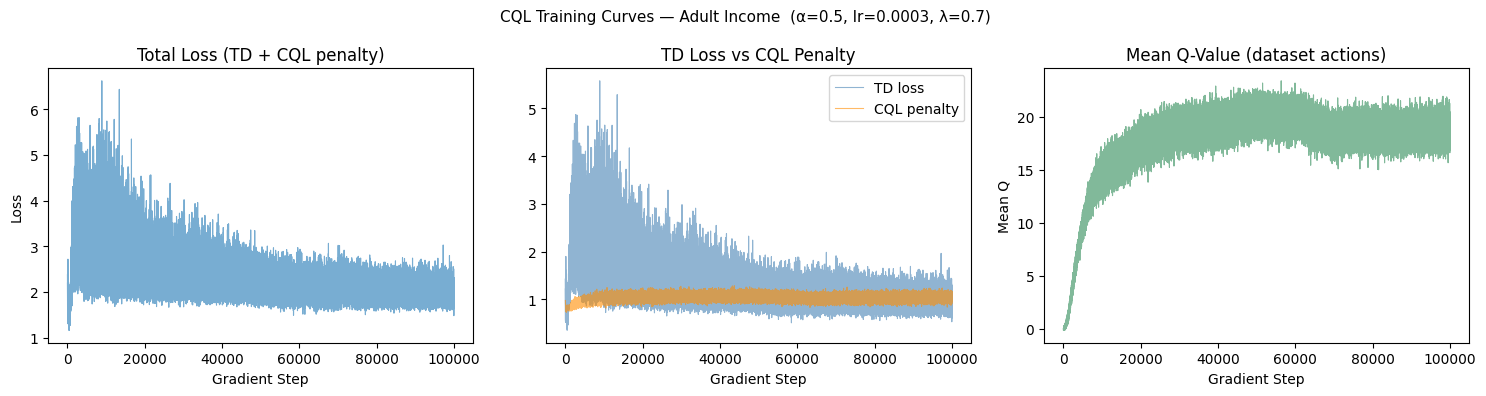

In [28]:
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history, alpha=0.6, linewidth=0.8)
axes[0].set_title('Total Loss (TD + CQL penalty)')
axes[0].set_xlabel('Gradient Step')
axes[0].set_ylabel('Loss')

axes[1].plot(td_history,  alpha=0.6, linewidth=0.8, label='TD loss',     color='steelblue')
axes[1].plot(cql_history, alpha=0.6, linewidth=0.8, label='CQL penalty', color='darkorange')
axes[1].set_title('TD Loss vs CQL Penalty')
axes[1].set_xlabel('Gradient Step')
axes[1].legend()

axes[2].plot(q_history, alpha=0.6, linewidth=0.8, color='seagreen')
axes[2].set_title('Mean Q-Value (dataset actions)')
axes[2].set_xlabel('Gradient Step')
axes[2].set_ylabel('Mean Q')

plt.suptitle(f'CQL Training Curves — Adult Income  (α={ALPHA}, lr={LR}, λ=0.7)', fontsize=11)
plt.tight_layout()
plt.savefig('plots/cql_training_curves_adult.png', dpi=120, bbox_inches='tight')
plt.show()


## Baseline Agents

In [29]:
def no_intervention_policy(state, info):
    """Always action 0 — never adjust thresholds."""
    return 0

def static_threshold_policy(state, info):
    """Fixed correction: always DECREASE Female threshold (action 4).
    Female has the lower positive prediction rate (~24% vs ~33% for Male) on
    Adult Income, so this is the dataset-appropriate static intervention —
    analogous to COMPAS's 'always decrease AA threshold' baseline."""
    return 4

def random_policy(state, info):
    return np.random.randint(0, N_ACTIONS_UCI)

def greedy_dp_policy(state, info):
    """DP-aware greedy: at each step, decrease the threshold of the group
    with the LOWEST positive prediction rate (raises that group's positive rate,
    narrows the DP gap). This is the same heuristic used in dataset generation."""
    if info is None:
        return 0
    pr_vals = info['metrics']['pr']
    worst = min(pr_vals, key=pr_vals.get)
    return {'Male': 2, 'Female': 4}[worst]

def cql_policy(state, info):
    """CQL: greedy w.r.t. trained Q-network."""
    return agent.select_action(state)

POLICIES = {
    'No Intervention': no_intervention_policy,
    'Static':          static_threshold_policy,
    'Random':          random_policy,
    'Greedy':          greedy_dp_policy,
    'CQL (ours)':      cql_policy,
}

print('Baselines defined:', list(POLICIES.keys()))


Baselines defined: ['No Intervention', 'Static', 'Random', 'Greedy', 'CQL (ours)']


## Evaluation

In [30]:
np.random.seed(99)
N_EVAL_EPISODES = 50

eval_results_adult = {name: {'rewards': [], 'acc': [], 'eo_gap': [], 'dp_gap': [],
                              'pr_M': [], 'pr_F': [], 'tpr_M': [], 'tpr_F': []}
                      for name in POLICIES}

for name, policy_fn in POLICIES.items():
    eval_env = FairnessEnvUCI(group_probs_dict, max_steps=50, seed=99)
    for ep in range(N_EVAL_EPISODES):
        state     = eval_env.reset()
        ep_reward = 0.0
        last_info = None
        ep_acc, ep_eo, ep_dp = [], [], []
        ep_pr_M, ep_pr_F = [], []
        ep_tpr_M, ep_tpr_F = [], []
        while True:
            action = policy_fn(state, last_info)
            state, reward, done, info = eval_env.step(action)
            ep_reward += reward
            m = info['metrics']
            ep_acc.append(m['accuracy'])
            ep_eo.append(m['eo_gap'])
            ep_dp.append(m['dp_gap'])
            ep_pr_M.append(m['pr']['Male'])
            ep_pr_F.append(m['pr']['Female'])
            ep_tpr_M.append(m['tpr']['Male'])
            ep_tpr_F.append(m['tpr']['Female'])
            last_info = info
            if done: break
        r = eval_results_adult[name]
        r['rewards'].append(ep_reward)
        r['acc'].append(np.mean(ep_acc))
        r['eo_gap'].append(np.mean(ep_eo))
        r['dp_gap'].append(np.mean(ep_dp))
        r['pr_M'].append(np.mean(ep_pr_M))
        r['pr_F'].append(np.mean(ep_pr_F))
        r['tpr_M'].append(np.mean(ep_tpr_M))
        r['tpr_F'].append(np.mean(ep_tpr_F))

    print(f'{name:20s} | reward={np.mean(eval_results_adult[name]["rewards"]):6.3f} | '
          f'acc={np.mean(eval_results_adult[name]["acc"]):.3f} | '
          f'dp_gap={np.mean(eval_results_adult[name]["dp_gap"]):.3f} | '
          f'eo_gap={np.mean(eval_results_adult[name]["eo_gap"]):.3f} | '
          f'pr_M={np.mean(eval_results_adult[name]["pr_M"]):.3f} | '
          f'pr_F={np.mean(eval_results_adult[name]["pr_F"]):.3f}')

import pandas as pd
summary = pd.DataFrame({
    name: {
        'Mean Reward':   np.mean(v['rewards']),
        'Mean Accuracy': np.mean(v['acc']),
        'Mean DP Gap':   np.mean(v['dp_gap']),
        'Mean EO Gap':   np.mean(v['eo_gap']),
        'P(+) Male':     np.mean(v['pr_M']),
        'P(+) Female':   np.mean(v['pr_F']),
    } for name, v in eval_results_adult.items()
}).T
print('\nSummary:')
print(summary.round(4))


No Intervention      | reward=11.770 | acc=0.802 | dp_gap=0.083 | eo_gap=0.021 | pr_M=0.159 | pr_F=0.076


Static               | reward= 6.674 | acc=0.738 | dp_gap=0.194 | eo_gap=0.324 | pr_M=0.159 | pr_F=0.350


Random               | reward=10.482 | acc=0.789 | dp_gap=0.102 | eo_gap=0.133 | pr_M=0.182 | pr_F=0.096


Greedy               | reward=14.139 | acc=0.730 | dp_gap=0.033 | eo_gap=0.042 | pr_M=0.359 | pr_F=0.335


CQL (ours)           | reward=14.342 | acc=0.752 | dp_gap=0.026 | eo_gap=0.060 | pr_M=0.295 | pr_F=0.284

Summary:
                 Mean Reward  Mean Accuracy  Mean DP Gap  Mean EO Gap  \
No Intervention      11.7699         0.8019       0.0831       0.0209   
Static                6.6743         0.7376       0.1945       0.3236   
Random               10.4817         0.7890       0.1024       0.1334   
Greedy               14.1395         0.7299       0.0325       0.0421   
CQL (ours)           14.3423         0.7518       0.0257       0.0605   

                 P(+) Male  P(+) Female  
No Intervention     0.1594       0.0763  
Static              0.1594       0.3500  
Random              0.1824       0.0957  
Greedy              0.3588       0.3347  
CQL (ours)          0.2954       0.2837  


## Baseline Comparison Plot

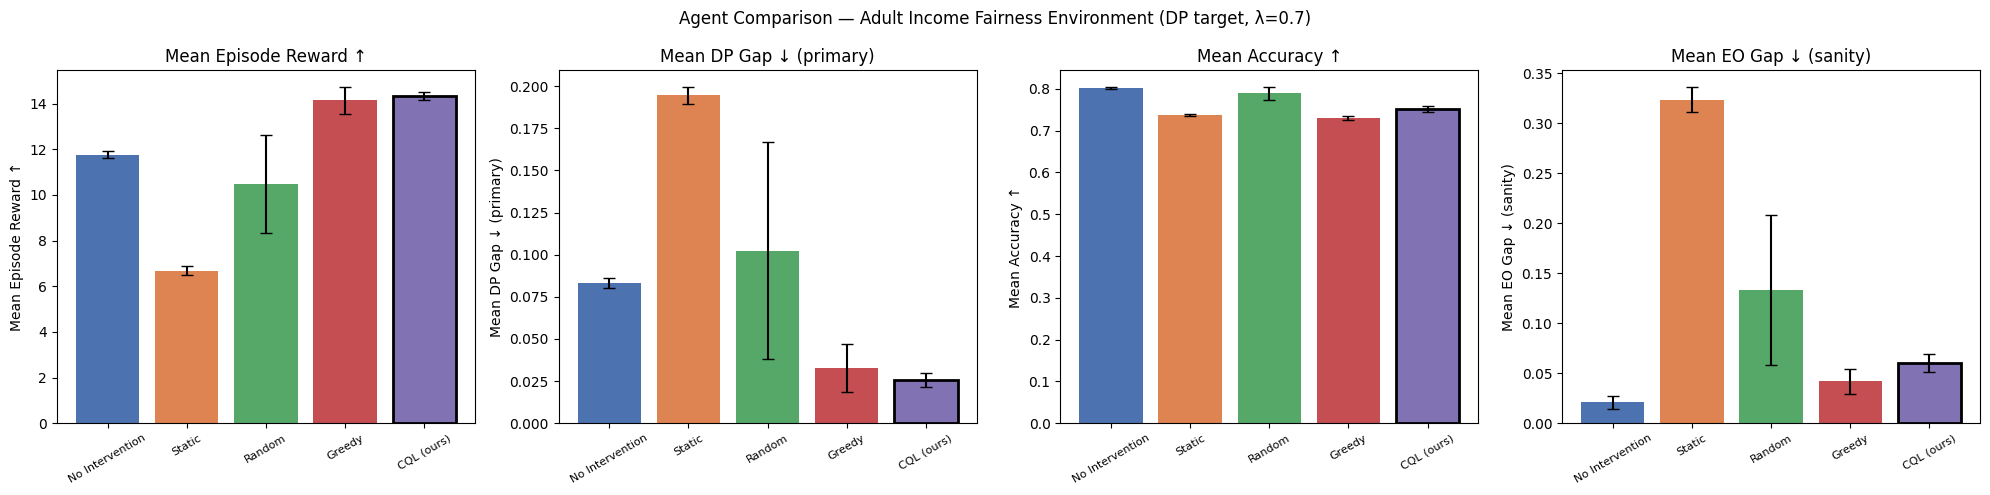

Saved plots/baseline_comparison_adult.png


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
names  = list(eval_results_adult.keys())
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

for ax, key, label in zip(axes,
                           ['rewards', 'dp_gap', 'acc', 'eo_gap'],
                           ['Mean Episode Reward ↑', 'Mean DP Gap ↓',
                            'Mean Accuracy ↑', 'Mean EO Gap ↓']):
    means = [np.mean(eval_results_adult[n][key]) for n in names]
    stds  = [np.std(eval_results_adult[n][key])  for n in names]
    bars  = ax.bar(names, means, yerr=stds, color=colors, capsize=4)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    for bar, name in zip(bars, names):
        if name == 'CQL (ours)':
            bar.set_edgecolor('black')
            bar.set_linewidth(2.0)

plt.suptitle('Agent Comparison — Adult Income Fairness Environment (DP target, λ=0.7)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/baseline_comparison_adult.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved plots/baseline_comparison_adult.png')


## Fairness–Accuracy Trade-off

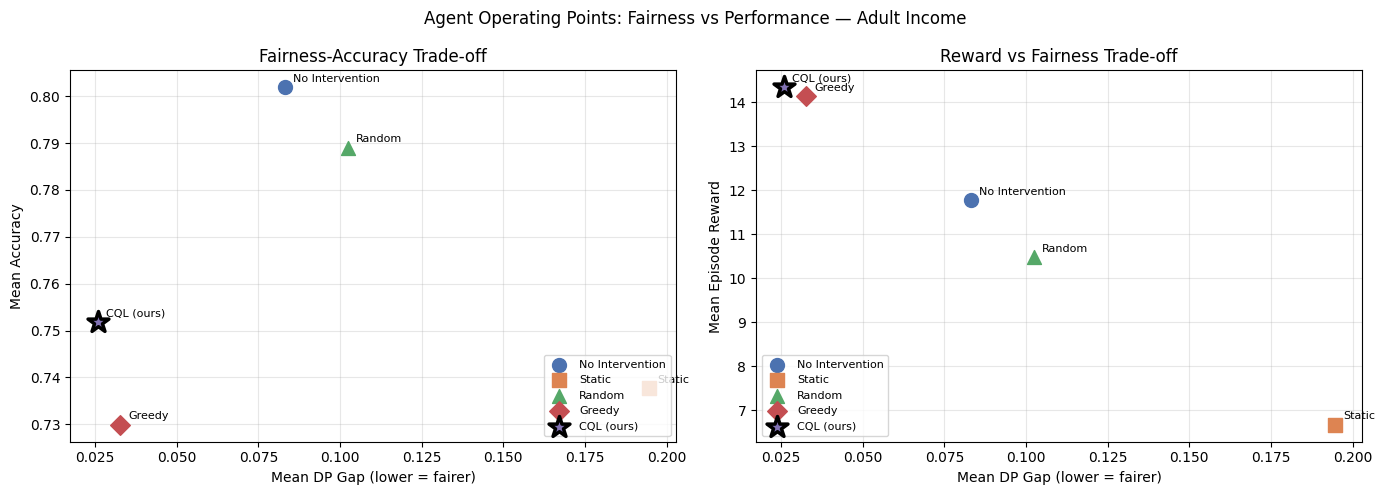

Fairness-Accuracy Summary:
  Agent                |   DP Gap |  Accuracy |   Reward
---------------------------------------------------------
  No Intervention      |    0.083 |     0.802 |   11.770
  Static               |    0.194 |     0.738 |    6.674
  Random               |    0.102 |     0.789 |   10.482
  Greedy               |    0.033 |     0.730 |   14.139
  CQL (ours)           |    0.026 |     0.752 |   14.342


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names   = list(eval_results_adult.keys())
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
markers = ['o', 's', '^', 'D', '*']
sizes   = [100, 100, 100, 100, 250]

for ax, y_key, y_label, title in [
    (axes[0], 'acc',     'Mean Accuracy',       'Fairness-Accuracy Trade-off'),
    (axes[1], 'rewards', 'Mean Episode Reward', 'Reward vs Fairness Trade-off'),
]:
    for name, color, marker, size in zip(names, colors, markers, sizes):
        dp_val = np.mean(eval_results_adult[name]['dp_gap'])
        y_val  = np.mean(eval_results_adult[name][y_key])
        ec     = 'black' if name == 'CQL (ours)' else color
        lw     = 2.5    if name == 'CQL (ours)' else 1.0
        ax.scatter(dp_val, y_val, color=color, marker=marker,
                   s=size, label=name, zorder=5, linewidths=lw, edgecolors=ec)
        ax.annotate(name, (dp_val, y_val), textcoords='offset points',
                    xytext=(6, 4), fontsize=8)
    ax.set_xlabel('Mean DP Gap (lower = fairer)')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    leg_loc = 'lower right' if y_key == 'acc' else 'lower left'
    ax.legend(fontsize=8, loc=leg_loc)
    ax.grid(alpha=0.3)

plt.suptitle('Agent Operating Points: Fairness vs Performance — Adult Income', fontsize=12)
plt.tight_layout()
plt.savefig('plots/fairness_accuracy_tradeoff_adult.png', dpi=120)
plt.show()

print('Fairness-Accuracy Summary:')
header = '  {:<20} | {:>8} | {:>9} | {:>8}'.format('Agent', 'DP Gap', 'Accuracy', 'Reward')
print(header)
print('-' * 57)
for name in names:
    dp  = np.mean(eval_results_adult[name]['dp_gap'])
    acc = np.mean(eval_results_adult[name]['acc'])
    rew = np.mean(eval_results_adult[name]['rewards'])
    print('  {:<20} | {:8.3f} | {:9.3f} | {:8.3f}'.format(name, dp, acc, rew))


## Per-Group Positive Prediction Rate

Replaces COMPAS's per-group TPR plot. Adult's TPRs are nearly equal at default
thresholds (EO gap ≈ 0.006), so a TPR plot would be uninformative. The
intervention's effect manifests in **P(predict=1) per group**, which is exactly
what DP gap measures.

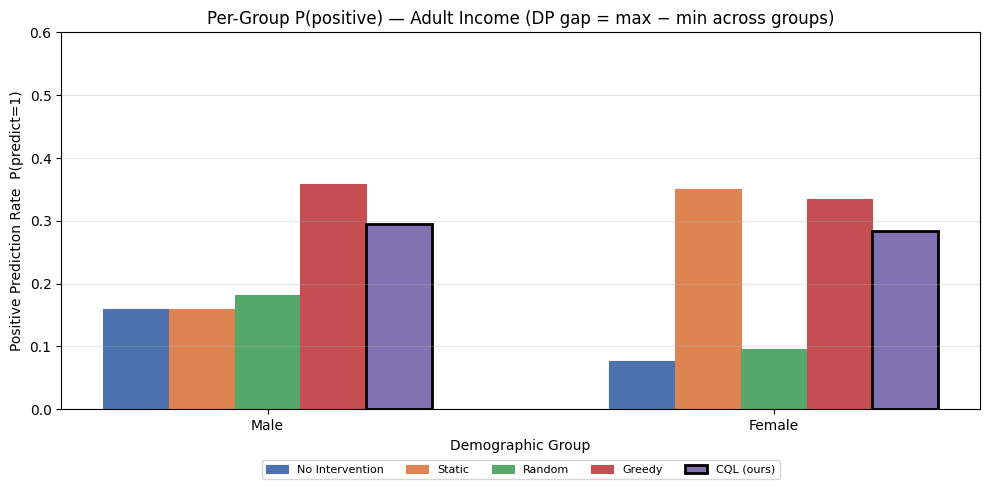

DP Gap (max P(positive) - min P(positive)):
  No Intervention     : 0.083
  Static              : 0.191
  Random              : 0.087
  Greedy              : 0.024
  CQL (ours)          : 0.012 ◀ ours


In [33]:
groups_label = ['Male', 'Female']
pr_keys      = ['pr_M', 'pr_F']
agent_names  = list(eval_results_adult.keys())
colors       = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

x     = np.arange(len(groups_label))
width = 0.13
n     = len(agent_names)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, color) in enumerate(zip(agent_names, colors)):
    pr_means = [np.mean(eval_results_adult[name][k]) for k in pr_keys]
    lw  = 2.0 if name == 'CQL (ours)' else 0.8
    ec  = 'black' if name == 'CQL (ours)' else color
    bars = ax.bar(x + offsets[i], pr_means, width, label=name,
                  color=color, edgecolor=ec, linewidth=lw)

ax.set_xlabel('Demographic Group')
ax.set_ylabel('Positive Prediction Rate  P(predict=1)')
ax.set_title('Per-Group P(positive) — Adult Income (DP gap = max − min across groups)')
ax.set_xticks(x)
ax.set_xticklabels(groups_label)
ax.set_ylim(0, max(0.6, ax.get_ylim()[1]))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=len(agent_names), frameon=True)
plt.tight_layout()
plt.savefig('plots/per_group_pr_adult.png', dpi=120, bbox_inches='tight')
plt.show()

print('DP Gap (max P(positive) - min P(positive)):')
for name in agent_names:
    pr_vals = [np.mean(eval_results_adult[name][k]) for k in pr_keys]
    dp = max(pr_vals) - min(pr_vals)
    marker = ' ◀ ours' if name == 'CQL (ours)' else ''
    print(f'  {name:<20}: {dp:.3f}{marker}')


## Trajectory Demonstration

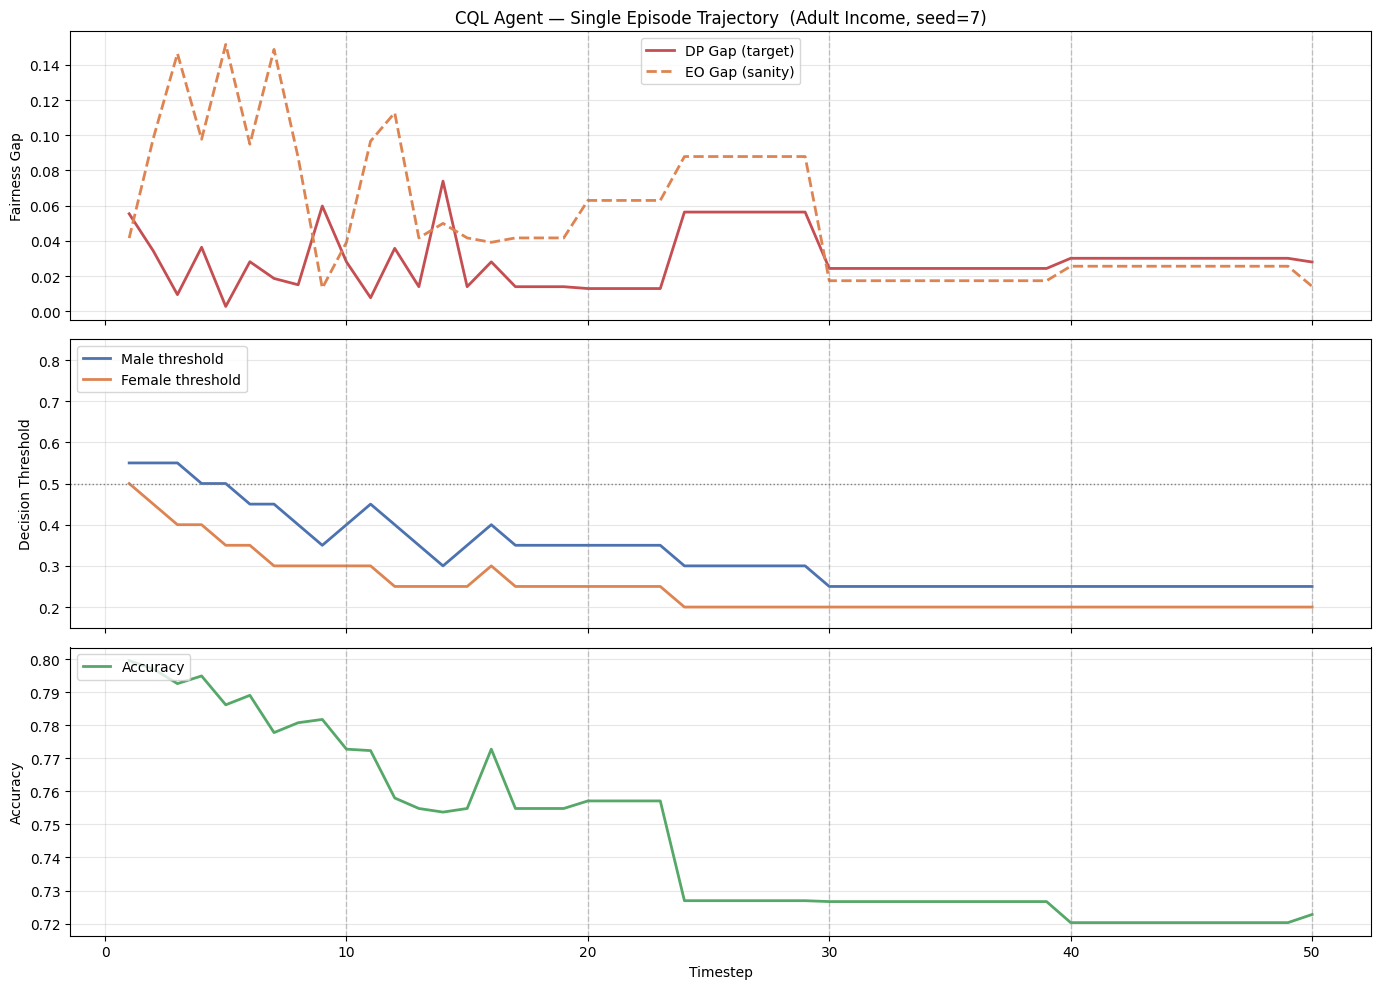

First 10 steps of CQL trajectory (Adult Income):
Step |     Action |  DP Gap |  EO Gap | Accuracy |  Reward
------------------------------------------------------------
   1 |     M thr+ |   0.055 |   0.042 |    0.800 |  0.2488
   2 |     F thr- |   0.034 |   0.098 |    0.797 |  0.2628
   3 |     F thr- |   0.010 |   0.146 |    0.793 |  0.2788
   4 |     M thr- |   0.036 |   0.098 |    0.795 |  0.2680
   5 |     F thr- |   0.003 |   0.152 |    0.786 |  0.2889
   6 |     M thr- |   0.028 |   0.095 |    0.789 |  0.2805
   7 |     F thr- |   0.019 |   0.149 |    0.778 |  0.2813
   8 |     M thr- |   0.015 |   0.087 |    0.781 |  0.2939
   9 |     M thr- |   0.060 |   0.013 |    0.782 |  0.2740
  10 |     M thr+ |   0.028 |   0.039 |    0.773 |  0.2805


In [34]:
demo_env = FairnessEnvUCI(group_probs_dict, max_steps=50, seed=7)
state = demo_env.reset()
last_info = None

traj = {'step': [], 'action': [], 'eo_gap': [], 'dp_gap': [], 'accuracy': [],
        'thr_M': [], 'thr_F': [], 'pr_M': [], 'pr_F': [], 'reward': []}

ACTION_LABELS_UCI = {
    0: 'No-op',  1: 'M thr+', 2: 'M thr-',
    3: 'F thr+', 4: 'F thr-', 5: 'All thr+', 6: 'All thr-'
}

done = False
while not done:
    action = agent.select_action(state)
    state, reward, done, info = demo_env.step(action)
    m = info['metrics']
    t = info['thresholds']
    traj['step'].append(demo_env.step_count)
    traj['action'].append(ACTION_LABELS_UCI[action])
    traj['eo_gap'].append(m['eo_gap'])
    traj['dp_gap'].append(m['dp_gap'])
    traj['accuracy'].append(m['accuracy'])
    traj['thr_M'].append(t['Male'])
    traj['thr_F'].append(t['Female'])
    traj['pr_M'].append(m['pr']['Male'])
    traj['pr_F'].append(m['pr']['Female'])
    traj['reward'].append(reward)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(traj['step'], traj['dp_gap'], label='DP Gap (target)', color='#C44E52', linewidth=2)
axes[0].plot(traj['step'], traj['eo_gap'], label='EO Gap', color='#DD8452', linewidth=2, linestyle='--')
axes[0].set_ylabel('Fairness Gap')
axes[0].set_title('CQL Agent — Single Episode Trajectory  (Adult Income, seed=7)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(traj['step'], traj['thr_M'], label='Male threshold',   color='#4C72B0', linewidth=2)
axes[1].plot(traj['step'], traj['thr_F'], label='Female threshold', color='#DD8452', linewidth=2)
axes[1].axhline(0.5, color='grey', linestyle=':', linewidth=1)
axes[1].set_ylabel('Decision Threshold')
axes[1].set_ylim(0.15, 0.85)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(traj['step'], traj['accuracy'], label='Accuracy', color='#55A868', linewidth=2)
axes[2].set_ylabel('Accuracy')
axes[2].set_xlabel('Timestep')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

for ax in axes:
    for drift_t in range(10, 51, 10):
        ax.axvline(drift_t, color='grey', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('plots/trajectory_demonstration_adult.png', dpi=120, bbox_inches='tight')
plt.show()

print('First 10 steps of CQL trajectory (Adult Income):')
header = '{:>4} | {:>10} | {:>7} | {:>7} | {:>8} | {:>7}'.format(
    'Step', 'Action', 'DP Gap', 'EO Gap', 'Accuracy', 'Reward')
print(header); print('-' * 60)
for i in range(min(10, len(traj['step']))):
    print('{:>4} | {:>10} | {:>7.3f} | {:>7.3f} | {:>8.3f} | {:>7.4f}'.format(
        traj['step'][i], traj['action'][i], traj['dp_gap'][i],
        traj['eo_gap'][i], traj['accuracy'][i], traj['reward'][i]))
